In [1]:
import numpy as np 
import pandas as pd 


In [2]:
df = pd.read_csv("data/spam.csv", sep="\t", header=None)

In [3]:
df.head()

,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.tail()

,0,1
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [5]:
df.rename(columns={0: 'target', 1: 'text'}, inplace=True)

<H2>Data cleaning</h2>

In [6]:
df.info(
)

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   target  5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [8]:
df['target'] = encoder.fit_transform(df['target'])

In [9]:
df.head(
)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
#check for duplicates
df.duplicated().sum()

np.int64(403)

In [11]:
#remove duplicates
df = df.drop_duplicates(keep='first')

In [12]:
df.head()
df.shape

(5169, 2)

In [13]:
#for confirmation
a = 5572-5169
print(a)

403


<h2>EDA</h2>

In [14]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt

([<matplotlib.patches.Wedge at 0x185a256de80>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

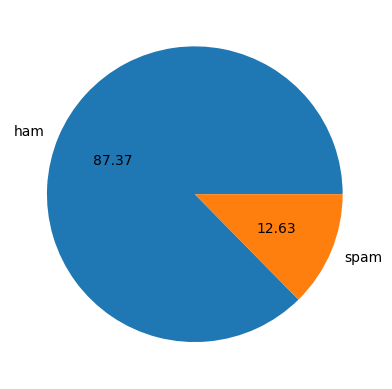

In [16]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')

In [17]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\soham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\soham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
df['no_char'] = df['text'].apply(len) #tofind no. of char in the text

In [19]:
df.shape

(5169, 3)

In [20]:
df.head()

,target,text,no_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
print(nltk.data.path)

['C:\\Users\\soham/nltk_data', 'c:\\Program Files\\Python314\\nltk_data', 'c:\\Program Files\\Python314\\share\\nltk_data', 'c:\\Program Files\\Python314\\lib\\nltk_data', 'C:\\Users\\soham\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data']


In [22]:
df['no_words']= df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [23]:
df.sample(n=5)

,target,text,no_char,no_words
4939,0,No it was cancelled yeah baby! Well that sound...,129,27
3504,0,Free any day but i finish at 6 on mon n thurs...,48,13
3528,0,Should i send you naughty pix? :),33,9
20,0,Is that seriously how you spell his name?,41,9
4305,0,"Good good, billy mates all gone. Just been jog...",77,18


In [24]:
df['no_sentences']= df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [25]:
df.head(
)

,target,text,no_char,no_words,no_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [26]:
df.describe()

,target,no_char,no_words,no_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,79.344554,18.593538,1.974076
std,0.332253,58.437457,13.402779,1.458967
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,61.000000,15.000000,1.000000
75%,0.000000,119.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [27]:
df[df['target'] == 0].describe()#ham mail

,target,no_char,no_words,no_sentences
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.905890,17.267715,1.827724
std,0.0,56.715046,13.588065,1.394338
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,53.000000,13.000000,1.000000
75%,0.0,91.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [28]:
#spam mail
df[df['target']==1].describe()

,target,no_char,no_words,no_sentences
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.704441,27.762634,2.986217
std,0.0,29.821348,6.993008,1.494815
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,148.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,223.000000,46.000000,9.000000


In [29]:
import seaborn as sns

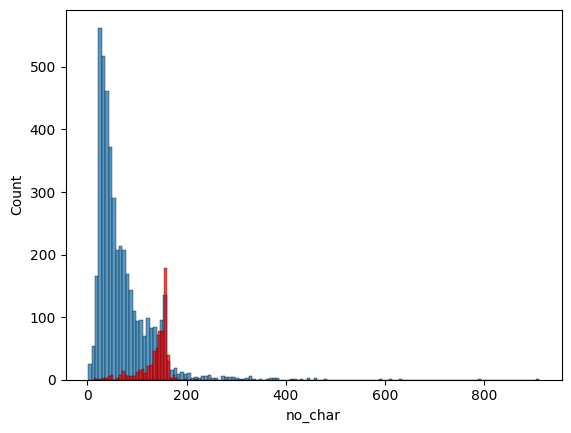

In [30]:
# sns.histplot(df[df['target'==0],['no_char']])
# the above syntax doesnt run as the string 'target'==0 is evaluated first. 
# Since the string 'target' does not equal the integer 0, it evaluates to False.
# now lets use other cleaner syntax
sns.histplot(data=df.loc[df['target'] == 0], x='no_char')
sns.histplot(data = df.loc[df['target']== 1], x = 'no_char',color = "red")
plt.show()
#.loc is label-based indexing , helps access the columns with their actual name 
#in the previous line py was comparing the string target with 0 
#instead of checking the values in the column target

<h4>Blue = ham = 0 , red = spam = 1</h4>
<p> As we can clearly see the no. of characters in ham are very less compared to spam
    bcz the distribution is skewed towards left i.e more no. of mails have less characters in it . 
    This will be followed for words as well
</p>

<Axes: >

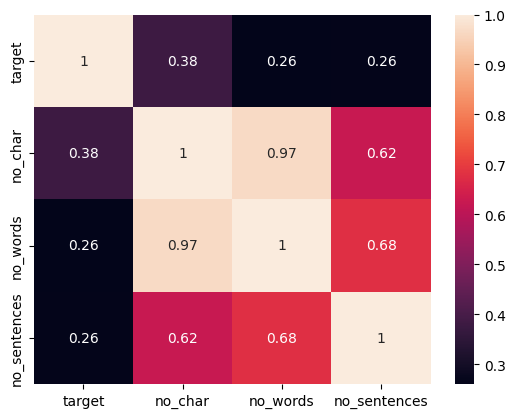

In [31]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
#as all columns in data frame are not numeric we set numeric_only

<H3>Analysis</h3>
<li>Corr_coef of characters is highest with target , i.e target is more dependant on no. of characters</li>
<li>Corr_coef of others is almost similar i.e of words with char , char with sentence and words with sentences</li>
<p>Since sentences depend on words and words on characters target is most dependent on no. of characters.<br> Hence we need to make a regression model with help of no. of characters </p>

<h2>Data Pre-Processing</h2>


<h5><ol>
    <li>Lower Case</li>
    <li>Tokenization</li>
</ol>
</h5>

In [35]:
from nltk.corpus import stopwords
import string

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')#Output will give token for the word dancing 

'danc'

In [52]:
#stopwords.words('english') <-gives eg. of stopwords
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    alnum_list=[]
    for i in text:
        if i.isalnum():
            alnum_list.append(i) #removing special characters
    text = alnum_list[:]
    alnum_list.clear()

    for i in text:
        #below line removes stop words(eg.are,am,I,is) and punctuations 
        if i not in stopwords.words('English') and i not in string.punctuation:
            alnum_list.append(i)

    text = alnum_list[:]
    alnum_list.clear()
#Below lines will tokenize the words using stemming and append it to the new list
    for i in text:
        alnum_list.append(ps.stem(i))

    return " ".join(alnum_list)

In [53]:
transform_text('Soham howww is the program running with the new $1000 laptop?')

'soham howww program run new 1000 laptop'

<p>In the above line howww is printed as it is a spelling error ,if it was correct spelling 'howww' wouldnt be appended to the list</p>

<h4>Add the tozens into i=new column for each row</h4>

In [54]:
df['transformed_text'] = df['text'].apply(transform_text)

In [55]:
df.head()

,target,text,no_char,no_words,no_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


"""from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color="white")

spam_wc = wc.generate(df[df['target]==1]['transformed_text].str.cat(sep=" "))
plt.imshow(spam_wc)

above lines will display a word cloud i.e the most occuring word will have 
biggest font and then decreasing fonts.. the most occuring words are call,
free,text , txt ,mobil,repli,u,tone,stop
"""


<h4>Finding MOst occuring words</h4>

In [66]:
spam_corpus =[]
#creating a continous list of all the rows
for msg in df[df['target']==1]['transformed_text'].tolist():
    #spliting the sentences into words and creating a list of these words
    for word in msg.split():
        spam_corpus.append(word)

In [83]:
from collections import Counter
most_common = pd.DataFrame(Counter(spam_corpus).most_common(30))
print(type(most_common))
most_common.head()


<class 'pandas.DataFrame'>


,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122


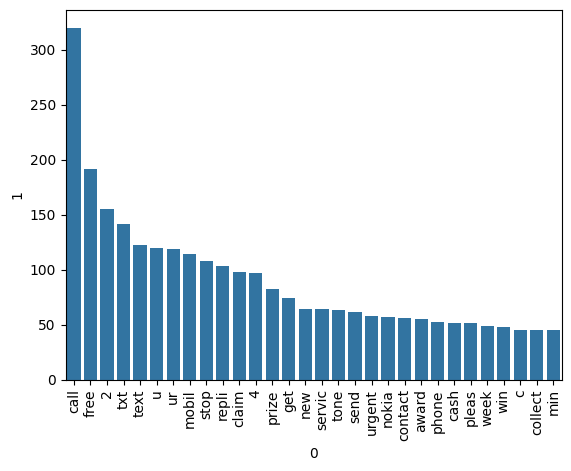

In [84]:
sns.barplot(x=most_common[0],y=most_common[1])
plt.xticks(rotation = "vertical")
plt.show()

In [85]:
spam_corpus_ham =[]
#creating a continous list of all the rows
for msg in df[df['target']==0]['transformed_text'].tolist():
    #spliting the sentences into words and creating a list of these words
    for word in msg.split():
        spam_corpus_ham.append(word)

In [86]:
from collections import Counter
most_common_ham = pd.DataFrame(Counter(spam_corpus_ham).most_common(30))
print(type(most_common_ham))
most_common_ham.head()

<class 'pandas.DataFrame'>


,0,1
0,u,897
1,go,407
2,get,351
3,2,288
4,gt,288


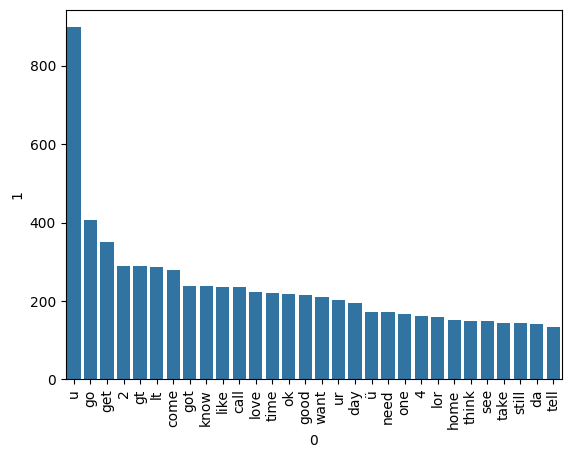

In [87]:
sns.barplot(x=most_common_ham[0],y=most_common_ham[1])
plt.xticks(rotation = "vertical")
plt.show()

<h2>Model Building</h2>
<ol><h4><li>Naive-Bayes</li></h4></ol>

In [120]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [121]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [122]:
X.shape


(5169, 3000)

In [123]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [126]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix

In [127]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [128]:
gnb.fit(X_train,y_train)
y_pred1 =gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8636363636363636
[[790 118]
 [ 23 103]]
0.4660633484162896


In [129]:
mnb.fit(X_train,y_train)
y_pred2 =mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9671179883945842
[[908   0]
 [ 34  92]]
1.0


<p>mnb with tfidf gives 100cent precision even tho accuracy is compromised,
since the data is imbalanced we care more abt the precision rather then accuracy</p>

In [130]:
bnb.fit(X_train,y_train)
y_pred3 =bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9738878143133463
[[906   2]
 [ 25 101]]
0.9805825242718447


In [118]:
#tfidf->mnb is a good choice for now


<h4>Model Improvement</h4>

In [131]:
# kept for further trial and errors
#added token limit of 3000

<h4>Creating pipeline</h4>
<h5>
<ol>
    <li>Text preprocessing</li>
    <li>
</ol>
</h5>